# 00 — Eksplorasi Data Mentah (PDF UU)

Notebook ini menjawab pertanyaan dasar sebelum kita menyentuh kode apapun:

- Seperti apa isi file PDF undang-undang?
- Artefak apa yang ada di dalamnya (nomor halaman, header, footer)?
- Bagaimana struktur dokumennya (BAB, Pasal, Ayat)?
- Apakah ada perbedaan antar UU yang perlu diperhatikan?

**Tidak ada prasyarat** — notebook ini hanya membutuhkan file PDF di `data/raw/`.

In [1]:
import sys, re
from pathlib import Path
from collections import Counter

import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from src.config import load_config, resolve_path

cfg = load_config()
raw_dir = resolve_path(cfg['paths']['raw_dir'])

# Daftar semua PDF yang tersedia
pdf_files = list(raw_dir.glob('*.pdf'))
print(f'PDF ditemukan: {len(pdf_files)}')
for p in sorted(pdf_files):
    print(f'  {p.name}  ({p.stat().st_size / 1024:.0f} KB)')

PDF ditemukan: 4
  UU Informasi dan Transaksi Elektronik.pdf  (567 KB)
  UU Ketenagakerjaan.pdf  (746 KB)
  UU Perlindungan Anak.pdf  (468 KB)
  UU Perlindungan Konsumen.pdf  (91 KB)


---
## 1. Ukuran Dokumen — Berapa Halaman Tiap UU?

In [2]:
info = []
for p in sorted(pdf_files):
    with pdfplumber.open(str(p)) as pdf:
        n_pages = len(pdf.pages)
        # Hitung total karakter teks
        total_chars = sum(len(pg.extract_text() or '') for pg in pdf.pages)
    info.append({'UU': p.stem, 'Halaman': n_pages, 'Total karakter': total_chars})

df_info = pd.DataFrame(info)
print(df_info.to_string(index=False))

                                   UU  Halaman  Total karakter
UU Informasi dan Transaksi Elektronik       38           60016
                   UU Ketenagakerjaan      230          169174
                 UU Perlindungan Anak       66           60106
             UU Perlindungan Konsumen       46           58123


---
## 2. Lihat Teks Mentah — Seperti Apa Isinya?

Kita lihat beberapa halaman pertama secara langsung untuk memahami struktur asli PDF.

In [3]:
# Pilih UU yang ingin dilihat
PDF_TARGET = raw_dir / 'UU Ketenagakerjaan.pdf'

pages = []
with pdfplumber.open(str(PDF_TARGET)) as pdf:
    for pg in pdf.pages:
        pages.append(pg.extract_text() or '')

print(f'Total halaman: {len(pages)}')
print()
# Tampilkan halaman ke-1 (biasanya cover/judul)
print('=== Halaman 1 ===')
print(pages[0])

Total halaman: 230

=== Halaman 1 ===
Undang-Undang Republik Indonesia
Nomor 13 Tahun 2003 (UU/2003/13) —
tentang Ketenagakerjaan
2003
Diekspor dari Wikisource pada 1 Juni 2026
1


In [4]:
# Halaman di tengah dokumen — biasanya berisi isi pasal
tengah = len(pages) // 2
print(f'=== Halaman {tengah + 1} (tengah dokumen) ===')
print(pages[tengah])

=== Halaman 116 (tengah dokumen) ===
6 (enam) bulan upah;
f. masa kerja 18 (delapan belas) tahun atau
lebih tetapi kurang dari 21 (dua puluh satu)
tahun, 7 (tujuh) bulan upah;
g. masa kerja 21 (dua puluh satu) tahun atau
lebih tetapi kurang dari 24 (dua puluh
empat) tahun, 8 (delapan) bulan upah;
h. masa kerja 24 (dua puluh empat) tahun atau
lebih, 10 (sepuluh ) bulan upah.
4. Uang penggantian hak yang seharusnya
diterima sebagaimana dimaksud dalam ayat (1)
meliputi :
a. cuti tahunan yang belum diambil dan belum
gugur;
b. biaya atau ongkos pulang untuk
pekerja/buruh dan keluarganya ketempat
dimana pekerja/buruh diterima bekerja;
c. penggantian perumahan serta pengobatan
dan perawatan ditetapkan 15% (lima belas
perseratus) dari uang pesangon dan/atau
uang penghargaan masa kerja bagi yang
memenuhi syarat;
d. hal-hal lain yang ditetapkan dalam
perjanjian kerja, peraturan perusahaan atau
perjanjian kerja bersama.
5. Perubahan perhitungan uang pesangon,
perhitungan uang penghargaan masa ker

In [5]:
# Halaman terakhir
print(f'=== Halaman {len(pages)} (terakhir) ===')
print(pages[-1])

=== Halaman 230 (terakhir) ===
RaymondSutanto
Imanuel NS Uen
Rimapavadria
-iNu-
IvanLanin
ReveurGAM
Transkerja
Bozky
Rocket000
Boris23
KABALINI
Bromskloss
Tene~commonswiki
AzaToth
Bender235
PatríciaR
230


---
## 3. Identifikasi Artefak PDF

Artefak adalah teks yang bukan bagian dari isi hukum — nomor halaman, header, footer — yang harus dibuang sebelum diproses.

In [6]:
raw_text = '\n\n'.join(pages)
all_lines = [ln.strip() for ln in raw_text.splitlines() if ln.strip()]

# --- Nomor halaman ---
_PAGE_NUM_RE = re.compile(r'^\d{1,4}$')
nomor_halaman = [ln for ln in all_lines if _PAGE_NUM_RE.match(ln)]
print(f'Baris nomor halaman : {len(nomor_halaman)} baris')
print(f'Contoh              : {nomor_halaman[:8]}')
print()

# --- Header/footer berulang ---
counts = Counter(
    ln for ln in all_lines
    if 0 < len(ln) <= 40
    and not ln.lower().startswith(('pasal', 'bab', 'ayat'))
)
footers = {ln: c for ln, c in counts.items() if c >= 5}
print(f'Header/footer berulang ({len(footers)} jenis):')
for f, c in sorted(footers.items(), key=lambda x: -x[1]):
    print(f'  [{c:>3}x]  "{f}"')

Baris nomor halaman : 231 baris
Contoh              : ['2003', '1', '2', '3', '4', '5', '6', '7']

Header/footer berulang (23 jenis):
  [271x]  "Cukup jelas."
  [ 12x]  "Huruf a"
  [ 12x]  "Huruf b"
  [  9x]  "Keputusan Menteri."
  [  9x]  "berlaku."
  [  9x]  "perundang-undangan yang berlaku."
  [  8x]  "pekerja/buruh."
  [  8x]  "ketenagakerjaan."
  [  8x]  "Menteri."
  [  8x]  "perjanjian kerja bersama."
  [  8x]  "bersangkutan."
  [  8x]  "Huruf c"
  [  8x]  "Huruf d"
  [  7x]  "kerja."
  [  7x]  "sebagaimana dimaksud dalam ayat (1)"
  [  6x]  "dan"
  [  6x]  "bersama."
  [  6x]  "upah;"
  [  5x]  "perusahaan."
  [  5x]  "dengan Peraturan Pemerintah."
  [  5x]  "dengan Keputusan Menteri."
  [  5x]  "dengan peraturan perundang-undangan yang"
  [  5x]  "pengusaha."


---
## 4. Distribusi Panjang Baris

Memahami distribusi panjang baris membantu kita menentukan threshold untuk mendeteksi artefak.

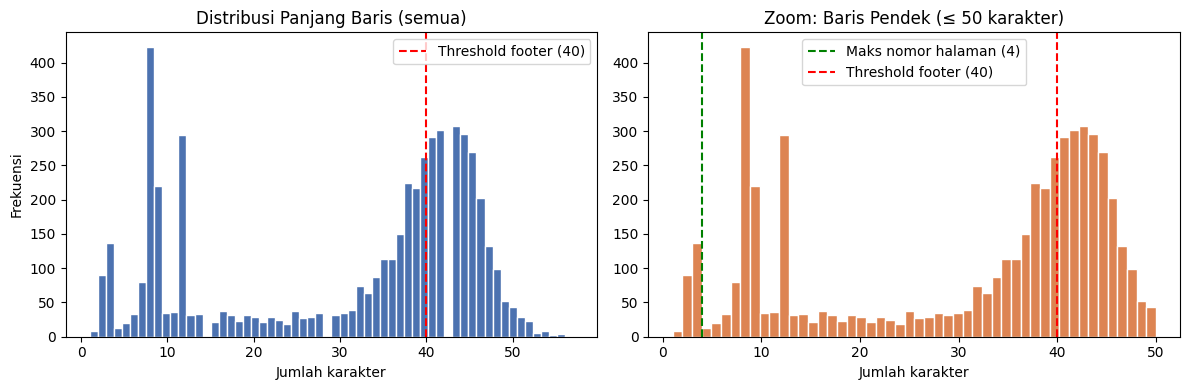

Total baris         : 5329
Baris ≤ 4 karakter  : 249  ← kandidat nomor halaman
Baris ≤ 40 karakter : 3259  ← kandidat header/footer


In [7]:
panjang_baris = [len(ln) for ln in all_lines]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram semua baris
axes[0].hist(panjang_baris, bins=60, color='#4C72B0', edgecolor='white')
axes[0].axvline(40, color='red', linestyle='--', label='Threshold footer (40)')
axes[0].set_title('Distribusi Panjang Baris (semua)')
axes[0].set_xlabel('Jumlah karakter'); axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Zoom: baris pendek (0-50 karakter)
pendek = [l for l in panjang_baris if l <= 50]
axes[1].hist(pendek, bins=50, color='#DD8452', edgecolor='white')
axes[1].axvline(4, color='green', linestyle='--', label='Maks nomor halaman (4)')
axes[1].axvline(40, color='red', linestyle='--', label='Threshold footer (40)')
axes[1].set_title('Zoom: Baris Pendek (≤ 50 karakter)')
axes[1].set_xlabel('Jumlah karakter'); axes[1].legend()

plt.tight_layout(); plt.show()
print(f'Total baris         : {len(all_lines)}')
print(f'Baris ≤ 4 karakter  : {sum(1 for l in panjang_baris if l <= 4)}  ← kandidat nomor halaman')
print(f'Baris ≤ 40 karakter : {sum(1 for l in panjang_baris if l <= 40)}  ← kandidat header/footer')

---
## 5. Struktur Dokumen — Preamble, BAB, dan Pasal

Setiap UU Indonesia memiliki struktur yang konsisten. Kita verifikasi apakah struktur ini ada dan dapat dideteksi dengan regex.

In [8]:
_BAB_RE   = re.compile(r'(?m)^BAB\s+([A-Z]+)\b')
_PASAL_RE = re.compile(r'(?m)^Pasal\s+(\d+[A-Za-z]*)\s*$')

babs   = _BAB_RE.findall(raw_text)
pasals = _PASAL_RE.findall(raw_text)

print(f'Jumlah BAB ditemukan   : {len(babs)}')
print(f'Jumlah Pasal ditemukan : {len(pasals)}')
print()
print('Daftar BAB :', babs)
print()
print('20 pasal pertama :', pasals[:20])
print('20 pasal terakhir:', pasals[-20:])

Jumlah BAB ditemukan   : 18
Jumlah Pasal ditemukan : 386

Daftar BAB : ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI', 'XII', 'XIII', 'XIV', 'XV', 'XVI', 'XVII', 'XVIII']

20 pasal pertama : ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']
20 pasal terakhir: ['174', '175', '176', '177', '178', '179', '180', '181', '182', '183', '184', '185', '186', '187', '188', '189', '190', '191', '192', '193']


In [9]:
# Deteksi preamble — teks sebelum BAB I
_BAB_SATU_RE = re.compile(r'^BAB\s+I\b', re.MULTILINE)
_MEMUTUSKAN_RE = re.compile(r'^MEMUTUSKAN', re.MULTILINE)

m = _BAB_SATU_RE.search(raw_text)
label_penanda = 'BAB I'
if m is None:
    m = _MEMUTUSKAN_RE.search(raw_text)
    label_penanda = 'MEMUTUSKAN (fallback — UU perubahan)'

if m:
    preamble = raw_text[:m.start()]
    print(f'Penanda awal isi UU : {label_penanda}')
    print(f'Panjang preamble    : {len(preamble):,} karakter ({len(preamble.splitlines())} baris)')
    print()
    print('=== 10 baris pertama preamble ===')
    for ln in preamble.splitlines()[:10]:
        if ln.strip(): print(' ', ln.strip())
else:
    print('Penanda tidak ditemukan.')

Penanda awal isi UU : BAB I
Panjang preamble    : 2,554 karakter (88 baris)

=== 10 baris pertama preamble ===
  Undang-Undang Republik Indonesia
  Nomor 13 Tahun 2003 (UU/2003/13) —
  tentang Ketenagakerjaan
  2003
  Diekspor dari Wikisource pada 1 Juni 2026
  1
  2
  Karya ini berada pada domain publik di


---
## 6. Perbandingan Antar UU

Ringkasan karakteristik setiap UU — berguna untuk memahami variasi data sebelum diproses.

In [ ]:
rows = []
for p in sorted(pdf_files):
    pages_local = []
    with pdfplumber.open(str(p)) as pdf:
        for pg in pdf.pages:
            pages_local.append(pg.extract_text() or '')
    full = '\n\n'.join(pages_local)
    n_bab   = len(_BAB_RE.findall(full))
    n_pasal = len(_PASAL_RE.findall(full))
    n_lines = len([l for l in full.splitlines() if l.strip()])
    has_bab1 = bool(_BAB_SATU_RE.search(full))
    rows.append({
        'UU': p.stem,
        'Halaman': len(pages_local),
        'Baris': n_lines,
        'BAB': n_bab,
        'Pasal terdeteksi': n_pasal,
        'Ada BAB I': '✓' if has_bab1 else '✗ (UU perubahan)'
    })

df_cmp = pd.DataFrame(rows)
print(df_cmp.to_string(index=False))

                                   UU  Halaman  Baris  BAB  Pasal terdeteksi        Ada BAB I
UU Informasi dan Transaksi Elektronik       38   1549   16                57                ✓
                   UU Ketenagakerjaan      230   5329   18               386                ✓
                 UU Perlindungan Anak       66   1930    3               169 ✗ (UU perubahan)
             UU Perlindungan Konsumen       46   1592   15               130                ✓


: 

---
## Kesimpulan Eksplorasi

Dari eksplorasi di atas, kita memahami:

1. **Artefak yang perlu dibersihkan:** nomor halaman (baris ≤ 4 karakter) dan header/footer berulang
2. **Preamble** setiap UU perlu dibuang — isinya bukan pasal, hanya bagian hukum formal pembukaan
3. **Penanda `BAB I`** dapat diandalkan sebagai titik awal isi UU, kecuali UU perubahan yang menggunakan `MEMUTUSKAN`
4. **Penanda `Pasal N`** berhasil mendeteksi semua kepala pasal — ini akan menjadi titik potong di tahap chunking

Langkah berikutnya → **`01_pengolahan_pdf.ipynb`**: pembersihan dan chunking step-by-step.